<a href="https://colab.research.google.com/github/EconShark/23_big_data_analysis_mid/blob/main/Case_Study_1/Phan%20tich%20ban%20hang%20voi%20PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân tích bán hàng với PySpark

## Sales Analytics with PySpark – UCI Online Retail II

**Mục tiêu:** xử lý hơn 1 triệu giao dịch và chuyển dữ liệu thành KPI, insight và đề xuất kinh doanh.

## Dataset
- **UCI Online Retail II**
- 1,067,371 giao dịch trong hai năm
- Nguồn: https://archive.ics.uci.edu/dataset/502/online+retail+ii
- DOI: 10.24432/C5CG6D
- License: CC BY 4.0

> Dataset gốc là Excel gồm hai sheet. Phần setup dưới đây tải và chuyển từng sheet sang CSV trước khi Spark đọc.

## Cài đặt và khởi tạo Spark

In [1]:
!pip -q install pyspark pandas openpyxl

In [2]:
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import *

spark = (SparkSession.builder
         .appName('SalesAnalyticsOnlineRetailII')
         .getOrCreate())

print('Spark version:', spark.version)

Spark version: 4.0.4


## Tải dữ liệu từ UCI và chuyển Excel sang CSV
Chạy cell này trên Colab/Jupyter có Internet. Nếu đã có `online_retail_II.csv`, có thể bỏ qua.

In [3]:
import os, zipfile, urllib.request, pandas as pd

URL = 'https://archive.ics.uci.edu/static/public/502/online%2Bretail%2Bii.zip'
ZIP_PATH = 'online_retail_II.zip'
EXTRACT_DIR = 'online_retail_II_raw'
CSV_PATH = 'online_retail_II.csv'

if not os.path.exists(CSV_PATH):
    if not os.path.exists(ZIP_PATH):
        urllib.request.urlretrieve(URL, ZIP_PATH)
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

    xlsx_files = [os.path.join(EXTRACT_DIR, f) for f in os.listdir(EXTRACT_DIR) if f.lower().endswith('.xlsx')]
    assert xlsx_files, 'Không tìm thấy file .xlsx'
    xlsx_path = xlsx_files[0]
    book = pd.ExcelFile(xlsx_path)
    first = True
    for sheet in book.sheet_names:
        print('Converting:', sheet)
        pdf = pd.read_excel(xlsx_path, sheet_name=sheet)
        pdf.to_csv(CSV_PATH, mode='w' if first else 'a', index=False, header=first)
        first = False
    print('Created:', CSV_PATH)
else:
    print('Found:', CSV_PATH)

Converting: Year 2009-2010
Converting: Year 2010-2011
Created: online_retail_II.csv


## 1. Data Understanding

In [4]:
sales_raw = spark.read.option('header', True).option('inferSchema', True).csv('online_retail_II.csv')
sales_raw.show(10, truncate=False)
sales_raw.printSchema()

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |22041    |"RECORD FRAME 7"" SINGLE SIZE "    |48      |2009-12-01 07:45:00|2.1  |13085.0    |United Kingdom|
|489434 |21232    |STRAWBERRY CERAMIC TRINKET BOX     |24      |2009-12-01 07:45:00|1.25 |13085.0    |United Kingdom|
|489434 |22064    |PINK DOUGHNUT TRINKET POT          |2

In [5]:
print('Rows:', sales_raw.count())
print('Columns:', len(sales_raw.columns))
print(sales_raw.columns)

Rows: 1067371
Columns: 8
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


### Bài tập 1. Khám phá dữ liệu
1. Đếm số hóa đơn, sản phẩm, khách hàng và quốc gia phân biệt.
2. Xác định min/max InvoiceDate.
3. Giải thích vì sao số dòng lớn hơn số hóa đơn.

In [6]:
sales_raw.select(
    F.countDistinct('Invoice').alias('Invoices') if 'Invoice' in sales_raw.columns else F.countDistinct('InvoiceNo').alias('Invoices')
).show()

+--------+
|Invoices|
+--------+
|   53628|
+--------+



> **Lưu ý:** UCI Online Retail II có thể dùng tên cột `Invoice`, `Price`, `Customer ID` thay vì `InvoiceNo`, `UnitPrice`, `CustomerID` tùy phiên bản file. Cell sau chuẩn hóa tên cột để phần còn lại của notebook thống nhất.

In [7]:
rename_map = {
    'Invoice':'InvoiceNo',
    'Price':'UnitPrice',
    'Customer ID':'CustomerID'
}
df = sales_raw
for old, new in rename_map.items():
    if old in df.columns:
        df = df.withColumnRenamed(old, new)
print(df.columns)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 2. Kiểm tra missing values và dữ liệu bất thường

In [8]:
missing = df.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns])
missing.show(truncate=False)

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|0        |0        |4382       |0       |0          |0        |243007    |0      |
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [9]:
df.select(
    F.sum((F.col('Quantity') <= 0).cast('int')).alias('Quantity_le_0'),
    F.sum((F.col('UnitPrice') <= 0).cast('int')).alias('UnitPrice_le_0'),
    F.sum(F.col('InvoiceNo').cast('string').startswith('C').cast('int')).alias('CancelledRows')
).show()

+-------------+--------------+-------------+
|Quantity_le_0|UnitPrice_le_0|CancelledRows|
+-------------+--------------+-------------+
|        22950|          6207|        19494|
+-------------+--------------+-------------+



### Bài tập 2. Data Cleaning
Tạo `sales_clean` với các giao dịch bán hợp lệ và `sales_customer` chỉ gồm các dòng có CustomerID.

In [10]:
df = df.withColumn('InvoiceDate', F.to_timestamp('InvoiceDate'))

df = df.withColumn('IsCancelled', F.col('InvoiceNo').cast('string').startswith('C'))

sales_clean = df.filter(
    (~F.col('IsCancelled')) &
    (F.col('Quantity') > 0) &
    (F.col('UnitPrice') > 0)
)

sales_customer = sales_clean.filter(F.col('CustomerID').isNotNull())

print('Raw rows:', df.count())
print('Clean rows:', sales_clean.count())
print('Customer rows:', sales_customer.count())

Raw rows: 1067371
Clean rows: 1041670
Customer rows: 805549


## 3. Feature Engineering

In [11]:
sales = (sales_clean
    .withColumn('Revenue', F.col('Quantity') * F.col('UnitPrice'))
    .withColumn('Date', F.to_date('InvoiceDate'))
    .withColumn('Year', F.year('InvoiceDate'))
    .withColumn('Month', F.month('InvoiceDate'))
    .withColumn('YearMonth', F.date_format('InvoiceDate', 'yyyy-MM'))
    .withColumn('DayOfWeek', F.date_format('InvoiceDate', 'E'))
    .withColumn('Hour', F.hour('InvoiceDate'))
)

sales.select('InvoiceNo','InvoiceDate','Quantity','UnitPrice','Revenue','YearMonth').show(10)

+---------+-------------------+--------+---------+------------------+---------+
|InvoiceNo|        InvoiceDate|Quantity|UnitPrice|           Revenue|YearMonth|
+---------+-------------------+--------+---------+------------------+---------+
|   489434|2009-12-01 07:45:00|      12|     6.95|              83.4|  2009-12|
|   489434|2009-12-01 07:45:00|      12|     6.75|              81.0|  2009-12|
|   489434|2009-12-01 07:45:00|      12|     6.75|              81.0|  2009-12|
|   489434|2009-12-01 07:45:00|      48|      2.1|100.80000000000001|  2009-12|
|   489434|2009-12-01 07:45:00|      24|     1.25|              30.0|  2009-12|
|   489434|2009-12-01 07:45:00|      24|     1.65|39.599999999999994|  2009-12|
|   489434|2009-12-01 07:45:00|      24|     1.25|              30.0|  2009-12|
|   489434|2009-12-01 07:45:00|      10|     5.95|              59.5|  2009-12|
|   489435|2009-12-01 07:46:00|      12|     2.55|30.599999999999998|  2009-12|
|   489435|2009-12-01 07:46:00|      12|

## 4. KPI tổng quan

In [12]:
kpi = sales.agg(
    F.sum('Revenue').alias('Revenue'),
    F.countDistinct('InvoiceNo').alias('Orders'),
    F.sum('Quantity').alias('UnitsSold'),
    F.countDistinct('CustomerID').alias('Customers')
).first()

revenue = float(kpi['Revenue'])
orders = int(kpi['Orders'])
units = int(kpi['UnitsSold'])
customers = int(kpi['Customers'])

print(f'Revenue: £{revenue:,.2f}')
print(f'Orders: {orders:,}')
print(f'Units sold: {units:,}')
print(f'Customers: {customers:,}')
print(f'AOV: £{revenue/orders:,.2f}')
print(f'Revenue/customer: £{revenue/customers:,.2f}')
print(f'Items/order: {units/orders:,.2f}')

Revenue: £20,972,594.57
Orders: 40,077
Units sold: 11,420,305
Customers: 5,878
AOV: £523.31
Revenue/customer: £3,567.98
Items/order: 284.96


### Yêu cầu
Viết 3–5 câu nhận xét về quy mô hoạt động dựa trên KPI trên.

## 5. Phân tích doanh thu theo thời gian

In [13]:
monthly = (sales.groupBy('YearMonth')
    .agg(
        F.sum('Revenue').alias('Revenue'),
        F.countDistinct('InvoiceNo').alias('Orders'),
        F.sum('Quantity').alias('Units')
    )
    .withColumn('AOV', F.col('Revenue')/F.col('Orders'))
    .orderBy('YearMonth'))
monthly.show(30, truncate=False)

+---------+------------------+------+------+------------------+
|YearMonth|Revenue           |Orders|Units |AOV               |
+---------+------------------+------+------+------------------+
|2009-12  |825685.7600000007 |1682  |426981|490.8952199762192 |
|2010-01  |652708.5020000001 |1105  |391525|590.6864271493214 |
|2010-02  |553339.7360000005 |1201  |382781|460.7325029142385 |
|2010-03  |833570.1309999995 |1681  |527401|495.87753182629353|
|2010-04  |681528.9919999992 |1462  |368198|466.1621012311896 |
|2010-05  |659858.8600000002 |1500  |397206|439.9059066666668 |
|2010-06  |752270.1400000008 |1645  |408636|457.30707598784244|
|2010-07  |650712.9399999998 |1529  |338920|425.58073250490503|
|2010-08  |697274.91         |1425  |473420|489.3157263157895 |
|2010-09  |924333.0109999999 |1839  |585357|502.628064709081  |
|2010-10  |1165483.9099999995|2301  |622095|506.5119122120815 |
|2010-11  |1470272.4820000017|2747  |728449|535.2284244630512 |
|2010-12  |1262598.7899999998|1559  |540

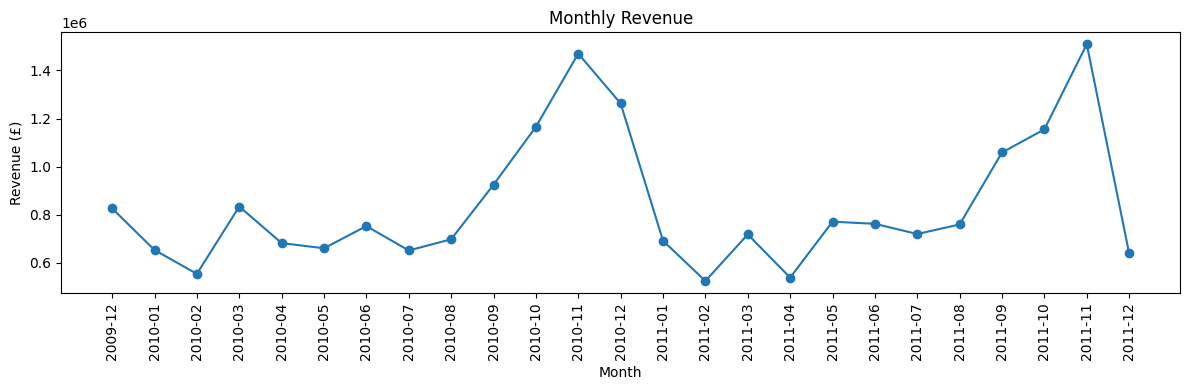

In [14]:
import matplotlib.pyplot as plt
monthly_pd = monthly.toPandas()
plt.figure(figsize=(12,4))
plt.plot(monthly_pd['YearMonth'], monthly_pd['Revenue'], marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Revenue')
plt.xlabel('Month'); plt.ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

### Bài tập 3
- Tìm 10 ngày doanh thu cao nhất.
- Phân tích doanh thu theo thứ trong tuần.
- Phân tích theo giờ.
- Nhận xét mùa vụ/cao điểm.

In [15]:
# TODO: doanh thu theo ngày / day-of-week / hour

## 6. Phân tích sản phẩm

In [16]:
product_sales = (sales.groupBy('StockCode','Description')
    .agg(
        F.sum('Revenue').alias('Revenue'),
        F.sum('Quantity').alias('Units'),
        F.countDistinct('InvoiceNo').alias('Orders')
    ))
product_sales.orderBy(F.desc('Revenue')).show(20, truncate=False)

+---------+-----------------------------------+------------------+-----+------+
|StockCode|Description                        |Revenue           |Units|Orders|
+---------+-----------------------------------+------------------+-----+------+
|22423    |REGENCY CAKESTAND 3 TIER           |344563.25000000064|27577|3918  |
|M        |Manual                             |340716.28000000026|10050|784   |
|DOT      |DOTCOM POSTAGE                     |322657.4800000002 |1436 |1415  |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER |262931.1599999977 |96086|5356  |
|23843    |PAPER CRAFT , LITTLE BIRDIE        |168469.6          |80995|1     |
|47566    |PARTY BUNTING                      |149187.05000000075|28378|2674  |
|85099B   |JUMBO BAG RED RETROSPOT            |148823.9200000017 |78860|3245  |
|84879    |ASSORTED COLOUR BIRD ORNAMENT      |132187.91999999864|81809|2807  |
|POST     |POSTAGE                            |127597.42         |5461 |1851  |
|22086    |PAPER CHAIN KIT 50'S CHRISTMA

### Bài tập 4
1. Top 20 theo Revenue.
2. Top 20 theo Units.
3. Top 20 theo Orders.
4. Tính tỷ trọng doanh thu Top 10/20/100.
5. Sản phẩm nào có Revenue cao nhưng Units không cao? Vì sao?

## 7. Phân tích thị trường theo quốc gia

In [17]:
country_sales = (sales.groupBy('Country')
    .agg(
        F.sum('Revenue').alias('Revenue'),
        F.countDistinct('InvoiceNo').alias('Orders'),
        F.countDistinct('CustomerID').alias('Customers')
    )
    .withColumn('AOV', F.col('Revenue')/F.col('Orders'))
    .orderBy(F.desc('Revenue')))
country_sales.show(20, truncate=False)

+---------------+--------------------+------+---------+------------------+
|Country        |Revenue             |Orders|Customers|AOV               |
+---------------+--------------------+------+---------+------------------+
|United Kingdom |1.7870977777004868E7|36535 |5350     |489.14678464499434|
|EIRE           |664431.7800000075   |626   |5        |1061.3926198083186|
|Netherlands    |554232.3400000011   |228   |22       |2430.8435964912333|
|Germany        |431262.46099999954  |789   |107      |546.5937401774393 |
|France         |356944.5999999994   |622   |95       |573.8659163987129 |
|Australia      |169968.1099999996   |95    |15       |1789.1379999999958|
|Spain          |109178.53000000006  |154   |41       |708.9514935064939 |
|Switzerland    |101011.29000000015  |93    |22       |1086.1429032258081|
|Sweden         |91903.71999999986   |105   |19       |875.2735238095224 |
|Denmark        |69862.19            |43    |12       |1624.7020930232559|
|Belgium        |65753.42

### Bài tập 5
- Top 10 quốc gia ngoài UK theo Revenue.
- So sánh AOV giữa các quốc gia có ≥ 50 orders.
- Thị trường quốc tế nào có tiềm năng nhất theo dữ liệu hiện có?

## 8. Phân tích khách hàng

In [18]:
cust = (sales_customer
    .withColumn('Revenue', F.col('Quantity')*F.col('UnitPrice'))
    .groupBy('CustomerID')
    .agg(
        F.sum('Revenue').alias('Revenue'),
        F.countDistinct('InvoiceNo').alias('Orders'),
        F.sum('Quantity').alias('Units')
    )
    .withColumn('AOV', F.col('Revenue')/F.col('Orders')))
cust.orderBy(F.desc('Revenue')).show(20)

+----------+------------------+------+------+------------------+
|CustomerID|           Revenue|Orders| Units|               AOV|
+----------+------------------+------+------+------------------+
|   18102.0| 608821.6499999999|   145|188340|4198.7699999999995|
|   14646.0| 528602.5199999999|   151|367193|3500.6789403973503|
|   14156.0|313946.36999999994|   156|165992|2012.4767307692305|
|   14911.0|295972.63000000006|   398|149987| 743.6498241206032|
|   17450.0|246973.08999999994|    51| 84720|4842.6096078431365|
|   13694.0|         196482.81|   143|189205|1374.0056643356643|
|   17511.0|175603.55000000002|    60|119656|2926.7258333333334|
|   16446.0|          168472.5|     2| 80997|          84236.25|
|   16684.0|         147142.77|    55|104810|2675.3230909090908|
|   12415.0|144458.36999999997|    28| 91447| 5159.227499999999|
|   15061.0|         137818.52|   127| 80711|1085.1851968503936|
|   16029.0|122209.14000000004|   107| 56486|1142.1414953271033|
|   17949.0|         1186

### Bài tập 6. Concentration
Tính tỷ trọng Revenue do Top 1%, 5%, 10% khách hàng tạo ra. Nhận xét mức độ tập trung.

In [19]:
# TODO: dùng Window để tính cumulative revenue share theo khách hàng

## 9. Phân tích RFM

In [20]:
max_date = sales_customer.agg(F.max('InvoiceDate')).first()[0]
reference_date = max_date

rfm = (sales_customer
    .withColumn('Revenue', F.col('Quantity')*F.col('UnitPrice'))
    .groupBy('CustomerID')
    .agg(
        F.datediff(F.lit(reference_date), F.max('InvoiceDate')).alias('Recency'),
        F.countDistinct('InvoiceNo').alias('Frequency'),
        F.sum('Revenue').alias('Monetary')
    ))
rfm.show(10)

+----------+-------+---------+------------------+
|CustomerID|Recency|Frequency|          Monetary|
+----------+-------+---------+------------------+
|   12467.0|    423|        1|132.79999999999998|
|   13094.0|     21|       13| 2433.120000000001|
|   17884.0|      3|       20|           3072.89|
|   17633.0|     31|        7|           2057.39|
|   14094.0|    439|        1|335.21999999999997|
|   15893.0|    481|        1|305.28000000000003|
|   14269.0|    439|        1|            295.73|
|   16596.0|     15|        4|            579.63|
|   14285.0|     21|        8|3284.4200000000005|
|   16916.0|     23|        4|1123.3999999999996|
+----------+-------+---------+------------------+
only showing top 10 rows


In [21]:
# Chấm điểm 1–5 bằng ntile
w_r = Window.orderBy(F.col('Recency').desc())   # recency thấp sẽ nhận score cao
w_f = Window.orderBy(F.col('Frequency'))
w_m = Window.orderBy(F.col('Monetary'))

rfm_scored = (rfm
    .withColumn('R', F.ntile(5).over(w_r))
    .withColumn('F', F.ntile(5).over(w_f))
    .withColumn('M', F.ntile(5).over(w_m))
    .withColumn('RFMScore', F.concat_ws('', 'R','F','M')))
rfm_scored.show(10)

+----------+-------+---------+-----------------+---+---+---+--------+
|CustomerID|Recency|Frequency|         Monetary|  R|  F|  M|RFMScore|
+----------+-------+---------+-----------------+---+---+---+--------+
|   14095.0|    722|        1|             2.95|  1|  1|  1|     111|
|   13788.0|    505|        1|             3.75|  1|  1|  1|     111|
|   16738.0|    297|        1|             3.75|  2|  1|  1|     211|
|   14792.0|     63|        1|              6.2|  3|  2|  1|     321|
|   15913.0|    534|        1|6.300000000000001|  1|  1|  1|     111|
|   15040.0|    541|        1|             7.49|  1|  1|  1|     111|
|   18115.0|    697|        1|              9.7|  1|  1|  1|     111|
|   17378.0|    374|        1|            10.95|  2|  1|  1|     211|
|   17956.0|    249|        1|            12.75|  2|  1|  1|     211|
|   16878.0|     84|        1|             13.3|  3|  2|  1|     321|
+----------+-------+---------+-----------------+---+---+---+--------+
only showing top 10 

### Bài tập 7. Segmentation
Tạo cột `Segment` theo logic gợi ý:
- Champions: R≥4, F≥4, M≥4
- Loyal: F≥4 và R≥3
- Potential Loyalist: R≥4 và F=2–3
- At Risk: R≤2 và F≥3
- Lost/Other: còn lại

Sau đó tính số khách hàng, doanh thu và Monetary trung bình theo segment.

In [22]:
rfm_segments = rfm_scored.withColumn(
    'Segment',
    F.when((F.col('R')>=4)&(F.col('F')>=4)&(F.col('M')>=4), 'Champions')
     .when((F.col('F')>=4)&(F.col('R')>=3), 'Loyal')
     .when((F.col('R')>=4)&(F.col('F').between(2,3)), 'Potential Loyalist')
     .when((F.col('R')<=2)&(F.col('F')>=3), 'At Risk')
     .otherwise('Lost/Other')
)

rfm_segments.groupBy('Segment').agg(
    F.count('*').alias('Customers'),
    F.sum('Monetary').alias('Revenue'),
    F.avg('Monetary').alias('AvgMonetary'),
    F.avg('Frequency').alias('AvgFrequency'),
    F.avg('Recency').alias('AvgRecency')
).orderBy(F.desc('Revenue')).show(truncate=False)

+------------------+---------+--------------------+------------------+------------------+-----------------+
|Segment           |Customers|Revenue             |AvgMonetary       |AvgFrequency      |AvgRecency       |
+------------------+---------+--------------------+------------------+------------------+-----------------+
|Champions         |1345     |1.2213762754999993E7|9080.86450185873  |16.610408921933086|19.30557620817844|
|Loyal             |721      |1911016.986         |2650.5089958391122|7.680998613037448 |76.31345353675451|
|At Risk           |708      |1563985.7519999996  |2209.019423728813 |5.427966101694915 |360.4901129943503|
|Lost/Other        |2343     |1343799.4349999994  |573.5379577464786 |1.5795988049509175|351.8506188647034|
|Potential Loyalist|761      |710864.2500000001   |934.1185939553221 |2.031537450722733 |26.40473061760841|
+------------------+---------+--------------------+------------------+------------------+-----------------+



## 10. Spark SQL

In [23]:
sales.createOrReplaceTempView('sales')

In [24]:
spark.sql('''
SELECT YearMonth,
       ROUND(SUM(Revenue), 2) AS Revenue,
       COUNT(DISTINCT InvoiceNo) AS Orders
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth
''').show(30)

+---------+----------+------+
|YearMonth|   Revenue|Orders|
+---------+----------+------+
|  2009-12| 825685.76|  1682|
|  2010-01|  652708.5|  1105|
|  2010-02| 553339.74|  1201|
|  2010-03| 833570.13|  1681|
|  2010-04| 681528.99|  1462|
|  2010-05| 659858.86|  1500|
|  2010-06| 752270.14|  1645|
|  2010-07| 650712.94|  1529|
|  2010-08| 697274.91|  1425|
|  2010-09| 924333.01|  1839|
|  2010-10|1165483.91|  2301|
|  2010-11|1470272.48|  2747|
|  2010-12|1262598.79|  1559|
|  2011-01| 691364.56|  1086|
|  2011-02| 523631.89|  1100|
|  2011-03| 717639.36|  1454|
|  2011-04| 537808.62|  1246|
|  2011-05| 770536.02|  1681|
|  2011-06|  761739.9|  1533|
|  2011-07| 719221.19|  1475|
|  2011-08| 759138.38|  1361|
|  2011-09|1058590.17|  1837|
|  2011-10| 1154979.3|  2040|
|  2011-11|1509496.33|  2769|
|  2011-12| 638810.68|   819|
+---------+----------+------+



### Bài tập 8. Viết thêm 5 truy vấn SQL
1. Top 10 sản phẩm theo Revenue.
2. Top 10 khách hàng theo Revenue.
3. Top 10 quốc gia ngoài UK.
4. Tháng có AOV cao nhất.
5. Sản phẩm xuất hiện trong nhiều hóa đơn nhất.

In [25]:
# TODO: Spark SQL queries

## 11. Pareto 80/20

In [26]:
total_product_revenue = product_sales.agg(F.sum('Revenue')).first()[0]
w = Window.orderBy(F.desc('Revenue')).rowsBetween(Window.unboundedPreceding, Window.currentRow)
pareto_products = (product_sales
    .orderBy(F.desc('Revenue'))
    .withColumn('CumRevenue', F.sum('Revenue').over(w))
    .withColumn('CumShare', F.col('CumRevenue') / F.lit(total_product_revenue)))
pareto_products.show(20, truncate=False)

+---------+-----------------------------------+------------------+-----+------+------------------+--------------------+
|StockCode|Description                        |Revenue           |Units|Orders|CumRevenue        |CumShare            |
+---------+-----------------------------------+------------------+-----+------+------------------+--------------------+
|22423    |REGENCY CAKESTAND 3 TIER           |344563.25000000064|27577|3918  |344563.25000000064|0.016429214272121326|
|M        |Manual                             |340716.28000000026|10050|784   |685279.530000001  |0.03267500011875494 |
|DOT      |DOTCOM POSTAGE                     |322657.4800000002 |1436 |1415  |1007937.0100000012|0.04805971939866275 |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER |262931.1599999977 |96086|5356  |1270868.169999999 |0.06059661172962774 |
|23843    |PAPER CRAFT , LITTLE BIRDIE        |168469.6          |80995|1     |1439337.769999999 |0.06862945666227382 |
|47566    |PARTY BUNTING                

### Câu hỏi
Bao nhiêu % sản phẩm tạo ra 80% doanh thu? Có thực sự là quy luật 80/20 không? Lặp lại phân tích cho khách hàng.

## 12. Executive Summary: Sinh viên phải hoàn thành
Viết ngắn gọn:
1. **5 insights quan trọng nhất**.
2. **3 hành động kinh doanh** dựa trên dữ liệu.
3. **2 hạn chế của dataset/phân tích**.

> Mỗi insight phải có số liệu hoặc biểu đồ hỗ trợ, tránh nhận xét chung chung.

## 13. Câu hỏi thảo luận
1. Vì sao không nên `toPandas()` toàn bộ dataset?
2. Vì sao phải giữ riêng thông tin giao dịch hủy thay vì xóa ngay từ đầu?
3. RFM có hạn chế gì?
4. Nếu dữ liệu tăng lên 100 triệu dòng, đâu là lợi thế của Spark?
5. Nếu có thêm cost/profit, bài phân tích nên thay đổi thế nào?

# Kết thúc